In [1]:
import pandas as pd
import numpy as np
import statsmodels.formula.api as smf
from scipy import stats
import matplotlib.pyplot as plt
import statsmodels.api as sm
import matplotlib.gridspec as gridspec
from matplotlib.lines import Line2D
from patsy import dmatrices
from statsmodels.miscmodels.ordinal_model import OrderedModel

In [2]:
pair = pd.read_excel('/content/pair_ИТОГ.xlsx')
long = pd.read_excel('/content/long_ИТОГ.xlsx')

## Balance check

а именно распределение этих переменных по группам: 'interesta + trust + pol_talks_online + outgroup_contacts + outgroup_pol_talks + pol_talks + fed_tv'

и вот этих: 'gender + age + educ + income + city'

In [3]:
suppl = long.drop_duplicates(subset=['rid'], keep='first')

In [4]:
suppl['support_bin'].value_counts()

,count
support_bin,
1,220
0,109


In [5]:
suppl[['set_id', 'interesta', 'trust','pol_talks_online', 'outgroup_contacts', 'outgroup_pol_talks', 'pol_talks', 'fed_tv', 'gender', 'age', 'educ', 'income', 'city']]

,set_id,interesta,trust,pol_talks_online,outgroup_contacts,outgroup_pol_talks,pol_talks,fed_tv,gender,age,educ,income,city
0,3,4,5.500000,1,3,3,3,2.333333,1,2,3,3,3
14,8,4,1.000000,1,5,1,1,1.000000,2,3,2,2,3
28,2,7,5.000000,5,4,4,7,3.000000,1,3,3,3,4
42,6,6,2.333333,4,4,4,4,4.333333,2,4,5,3,3
56,7,3,4.166667,1,1,1,1,2.000000,2,3,3,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4536,9,4,4.333333,2,2,2,3,2.333333,2,1,4,4,3
4550,10,3,4.666667,1,2,2,1,1.000000,2,2,5,4,1
4564,1,4,1.833333,3,2,2,2,1.333333,1,2,5,3,2
4578,2,6,7.000000,7,7,7,7,3.666667,2,1,4,4,2


In [6]:
suppl['set_id'].value_counts()

,count
set_id,
3,41
6,40
2,37
4,35
9,33
10,32
1,31
5,29
8,26


In [7]:
continuous_vars = ['trust', 'fed_tv']
discrete_vars = ['pol_talks_online', 'outgroup_contacts', 'outgroup_pol_talks', 'pol_talks', 'interesta']
socdem_vars = ['gender', 'age', 'educ', 'income', 'city']

results = []

for var in continuous_vars + discrete_vars:
    groups = [g[var].dropna().values for _, g in suppl.groupby('set_id')]
    stat, p = stats.kruskal(*groups)
    results.append({'Переменная': var, 'Тест': 'Краскел-Уоллис', 'Статистика': round(stat, 3), 'p-value': round(p, 3)})

for var in socdem_vars:
    contingency = pd.crosstab(suppl['set_id'], suppl[var])
    chi2, p, dof, _ = stats.chi2_contingency(contingency)
    results.append({'Переменная': var, 'Тест': 'Хи-квадрат', 'Статистика': round(chi2, 3), 'p-value': round(p, 3)})

result_df = pd.DataFrame(results)
result_df['Значимо'] = result_df['p-value'].apply(lambda p: '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else '—')))

print(result_df.to_string(index=False))

        Переменная           Тест  Статистика  p-value Значимо
             trust Краскел-Уоллис       9.059    0.432       —
            fed_tv Краскел-Уоллис       8.335    0.501       —
  pol_talks_online Краскел-Уоллис       7.363    0.599       —
 outgroup_contacts Краскел-Уоллис      12.639    0.180       —
outgroup_pol_talks Краскел-Уоллис      15.251    0.084       —
         pol_talks Краскел-Уоллис      12.826    0.171       —
         interesta Краскел-Уоллис      15.383    0.081       —
            gender     Хи-квадрат      17.535    0.041       *
               age     Хи-квадрат      30.352    0.954       —
              educ     Хи-квадрат      39.974    0.298       —
            income     Хи-квадрат      31.521    0.682       —
              city     Хи-квадрат      33.650    0.581       —


# **1. H1**

среди двух кандидатов, в условиях отсутствия информации о занимаемых ими позициях по вопросам, более положительные оценки в среднем будут получать кандидаты, представляющие политическую ин-группу респондента, чем кандидаты, представляющие политическую аут-группу.

### подтвердилась

In [8]:
# все контроли
covariats = 'interesta + trust + pol_talks_online + outgroup_contacts + outgroup_pol_talks + pol_talks + fed_tv'
soc_dem = 'C(gender) + age + educ + income + C(city)'
cands = 'age_gap + same_gender_pair'

In [9]:
long.columns

Index(['Unnamed: 0', 'rid', 'interesta', 'identa', 'identb', 'trust',
       'pol_talks_online', 'outgroup_contacts', 'outgroup_pol_talks',
       'pol_talks', 'fed_tv', 'support_bin', 'patra', 'imppatra', 'euthana',
       'impeuthana', 'gender', 'age', 'educ', 'income', 'city', 'set_id',
       'position_in_set', 'var_name', 'vignette_code', 'topic', 'combo',
       'candidate', 'rating', 'cand_support_bin', 'cand_gender', 'cand_age',
       'ingroup', 'resp_issue_pos', 'cand_issue_pos', 'issue_match',
       'age_outgroup', 'age_ingroup', 'age_gap', 'gender_outgroup',
       'gender_ingroup', 'same_gender_pair', 'rating_ingroup',
       'rating_outgroup', 'ap', 'issue_match_ingroup', 'issue_match_outgroup',
       'resp_issue_importance'],
      dtype='object')

In [10]:
# эту гипотезу проверим на массиве long, т.к. речь идет про сравнение оценок для двух кандидатов
long_h1 = long[(long['topic'] == 'nopos')]

print(f"Строк: {len(long_h1)}")
print(f"Респондентов: {long_h1['rid'].nunique()}")
long_h1

Строк: 658
Респондентов: 329


,Unnamed: 0,rid,interesta,identa,identb,trust,pol_talks_online,outgroup_contacts,outgroup_pol_talks,pol_talks,...,age_gap,gender_outgroup,gender_ingroup,same_gender_pair,rating_ingroup,rating_outgroup,ap,issue_match_ingroup,issue_match_outgroup,resp_issue_importance
6,6,1,4,5,2,5.500000,1,3,3,3,...,-22,мужчина,мужчина,1,6,6,0,NaN,NaN,NaN
7,7,1,4,5,2,5.500000,1,3,3,3,...,-22,мужчина,мужчина,1,6,6,0,NaN,NaN,NaN
22,22,2,4,1,7,1.000000,1,5,1,1,...,-16,женщина,мужчина,0,11,2,9,NaN,NaN,NaN
23,23,2,4,1,7,1.000000,1,5,1,1,...,-16,женщина,мужчина,0,11,2,9,NaN,NaN,NaN
34,34,3,7,4,5,5.000000,5,4,4,7,...,-38,мужчина,мужчина,1,9,4,5,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4571,4571,327,4,4,4,1.833333,3,2,2,2,...,-16,женщина,женщина,1,10,3,7,NaN,NaN,NaN
4584,4584,328,6,7,2,7.000000,7,7,7,7,...,-38,мужчина,мужчина,1,11,1,10,NaN,NaN,NaN
4585,4585,328,6,7,2,7.000000,7,7,7,7,...,-38,мужчина,мужчина,1,11,1,10,NaN,NaN,NaN
4600,4600,329,7,1,7,1.666667,1,4,4,4,...,-38,мужчина,мужчина,1,11,1,10,NaN,NaN,NaN


In [11]:
# средний рейтинг аут-группы и ин-группы
long_h1.groupby("ingroup")["rating"].agg(["count", "mean", "std"])

,count,mean,std
ingroup,,,
0,329,3.753799,2.404935
1,329,8.042553,2.289560


In [12]:
# базовая
m_h1_long_base = smf.ols('rating ~ ingroup', data=long_h1).fit(cov_type='cluster', cov_kwds={'groups': long_h1['rid']})
print(m_h1_long_base.summary())

                            OLS Regression Results                            
Dep. Variable:                 rating   R-squared:                       0.456
Model:                            OLS   Adj. R-squared:                  0.455
Method:                 Least Squares   F-statistic:                     363.4
Date:                Sun, 14 Jun 2026   Prob (F-statistic):           4.67e-55
Time:                        16:33:22   Log-Likelihood:                -1494.3
No. Observations:                 658   AIC:                             2993.
Df Residuals:                     656   BIC:                             3002.
Df Model:                           1                                         
Covariance Type:              cluster                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      3.7538      0.133     28.290      0.0

In [13]:
# ДОБАВИМ КОВАРИАТЫ
m_h1_long_covs = smf.ols(f'rating ~ ingroup + {covariats} ', data=long_h1).fit(cov_type='cluster', cov_kwds={'groups': long_h1['rid']})
print(m_h1_long_covs.summary())

                            OLS Regression Results                            
Dep. Variable:                 rating   R-squared:                       0.470
Model:                            OLS   Adj. R-squared:                  0.463
Method:                 Least Squares   F-statistic:                     65.46
Date:                Sun, 14 Jun 2026   Prob (F-statistic):           1.96e-63
Time:                        16:34:09   Log-Likelihood:                -1485.5
No. Observations:                 658   AIC:                             2989.
Df Residuals:                     649   BIC:                             3030.
Df Model:                           8                                         
Covariance Type:              cluster                                         
                         coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept              2.8836      0

In [14]:
# ДОБАВИМ СОЦ-ДЕМ КОНТРОЛИ
m_h1_long_soc = smf.ols(f'rating ~ ingroup + {soc_dem} ', data=long_h1).fit(cov_type='cluster', cov_kwds={'groups': long_h1['rid']})
print(m_h1_long_soc.summary())

                            OLS Regression Results                            
Dep. Variable:                 rating   R-squared:                       0.458
Model:                            OLS   Adj. R-squared:                  0.450
Method:                 Least Squares   F-statistic:                     42.82
Date:                Sun, 14 Jun 2026   Prob (F-statistic):           2.73e-50
Time:                        16:34:19   Log-Likelihood:                -1492.8
No. Observations:                 658   AIC:                             3006.
Df Residuals:                     648   BIC:                             3051.
Df Model:                           9                                         
Covariance Type:              cluster                                         
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept          3.9961      0.439      9.

In [15]:
# ДОБАВИМ И КОВАРИАТЫ И КОНТРОЛИ
m_h1_long_itog = smf.ols(f'rating ~ ingroup + {covariats} + {soc_dem} ', data=long_h1).fit(cov_type='cluster', cov_kwds={'groups': long_h1['rid']})
print(m_h1_long_itog.summary())

                            OLS Regression Results                            
Dep. Variable:                 rating   R-squared:                       0.472
Model:                            OLS   Adj. R-squared:                  0.459
Method:                 Least Squares   F-statistic:                     34.31
Date:                Sun, 14 Jun 2026   Prob (F-statistic):           2.60e-60
Time:                        16:34:26   Log-Likelihood:                -1484.2
No. Observations:                 658   AIC:                             3002.
Df Residuals:                     641   BIC:                             3079.
Df Model:                          16                                         
Covariance Type:              cluster                                         
                         coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept              3.2926      0

In [41]:
!pip install stargazer

In [42]:
from stargazer.stargazer import Stargazer

sg = Stargazer([m_h1_long_base, m_h1_long_covs, m_h1_long_itog])

sg.title('Сравнение средних оценок кандидатов из ин-группы и аут-группы')
# sg.custom_columns(['Парная', 'С контролями', 'Full controls + Deck FE'], [1, 1, 1])

sg.covariate_order([
    'ingroup'
])



# sg.rename_covariates({
#     'C(h2_condition, Treatment(reference="nopos"))[T.both_match]':            'Both match',
#     'C(h2_condition, Treatment(reference="nopos"))[T.both_mismatch]':         'Both mismatch',
#     'C(h2_condition, Treatment(reference="nopos"))[T.in_match_out_mismatch]': 'In-match / Out-mismatch',
#     'C(h2_condition, Treatment(reference="nopos"))[T.in_mismatch_out_match]': 'In-mismatch / Out-match',
#     'position_in_set': 'Vignette position',
# })

sg.add_line('Political controls',        ['', '$\\checkmark$', '$\\checkmark$'])
sg.add_line('Sociodemographic controls', ['', '', '$\\checkmark$'])


print(sg.render_latex())

\begin{table}[!htbp] \centering
  \caption{Сравнение средних оценок кандидатов из ин-группы и аут-группы}
\begin{tabular}{@{\extracolsep{5pt}}lccc}
\\[-1.8ex]\hline
\hline \\[-1.8ex]
& \multicolumn{3}{c}{\textit{Dependent variable: rating}} \
\cr \cline{2-4}
\\[-1.8ex] & (1) & (2) & (3) \\
\hline \\[-1.8ex]
 ingroup & 4.289$^{***}$ & 4.289$^{***}$ & 4.289$^{***}$ \\
& (0.225) & (0.226) & (0.228) \\
 Political controls &  & $\checkmark$ & $\checkmark$ \\
 Sociodemographic controls &  &  & $\checkmark$ \\
\hline \\[-1.8ex]
 Observations & 658 & 658 & 658 \\
 $R^2$ & 0.456 & 0.470 & 0.472 \\
 Adjusted $R^2$ & 0.455 & 0.463 & 0.459 \\
 Residual Std. Error & 2.348 (df=656) & 2.329 (df=649) & 2.339 (df=641) \\
 F Statistic & 363.404$^{***}$ (df=1; 656) & 65.457$^{***}$ (df=8; 649) & 34.311$^{***}$ (df=16; 641) \\
\hline
\hline \\[-1.8ex]
\textit{Note:} & \multicolumn{3}{r}{$^{*}$p$<$0.1; $^{**}$p$<$0.05; $^{***}$p$<$0.01} \\
\end{tabular}
\end{table}


In [16]:
# ПРОВЕРИМ ЭФФЕКТ ИНГРУППЫ В ЗАВИСИМОСТИ ОТ ПОРЯДКОВОГО НОМЕРА ВИНЬЕТКИ
ingroup_by_position = []
for pos in sorted(long_h1["position_in_set"].unique()):
    data_pos = long_h1[long_h1["position_in_set"] == pos]

    m_pos = smf.ols(f'rating ~ ingroup + {covariats} + {soc_dem}', data=data_pos).fit(cov_type="cluster", cov_kwds={"groups": data_pos["rid"]})

    coef = m_pos.params["ingroup"]
    se = m_pos.bse["ingroup"]

    ingroup_by_position.append({
        "position_in_set": pos,
        "coef": coef,
        "se": se,
        "ci_low": coef - 1.96 * se,
        "ci_high": coef + 1.96 * se,
        "p_value": m_pos.pvalues["ingroup"],
        "n_obs": int(m_pos.nobs),
        "n_clusters": data_pos["rid"].nunique()
    })

ingroup_by_position = pd.DataFrame(ingroup_by_position)
ingroup_by_position


,position_in_set,coef,se,ci_low,ci_high,p_value,n_obs,n_clusters
0,1,4.156250,0.783426,2.620735,5.691765,1.125355e-07,64,32
1,3,3.360000,0.979902,1.439392,5.280608,6.060005e-04,50,25
2,4,3.953704,0.400865,3.168009,4.739398,6.025715e-23,216,108
3,6,4.637255,0.410296,3.833074,5.441436,1.279545e-29,204,102
4,7,4.741935,0.609913,3.546506,5.937364,7.558066e-15,124,62


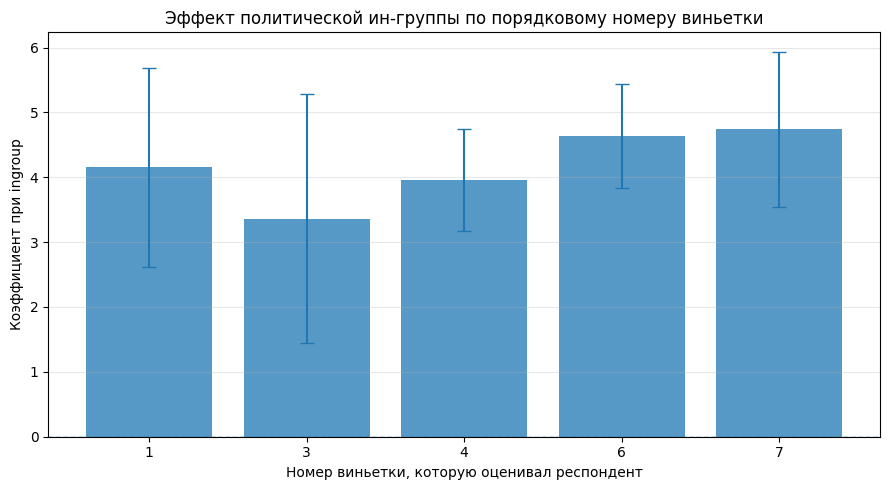

In [17]:
plot_df = ingroup_by_position.sort_values("position_in_set").copy()

x = np.arange(len(plot_df))

yerr = np.vstack([plot_df["coef"] - plot_df["ci_low"], plot_df["ci_high"] - plot_df["coef"]])

plt.figure(figsize=(9, 5))
plt.bar(x, plot_df["coef"], alpha=0.75)
plt.errorbar(x, plot_df["coef"], yerr=yerr, fmt="none", capsize=5, linewidth=1.5)
plt.axhline(0, linestyle="--", linewidth=1)
plt.xticks(x, plot_df["position_in_set"].astype(str))

plt.xlabel("Номер виньетки, которую оценивал респондент")
plt.ylabel("Коэффициент при ingroup")
plt.title("Эффект политической ин-группы по порядковому номеру виньетки")

plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

In [18]:
# МОДЕЛЬ С ПЕРЕМЕННОЙ ВЗАИМОДЕЙСТВИЯ ИНГРУППА * НОМЕР ВИНЬЕТКИ
m_h1_position_inter = smf.ols(f'rating ~ ingroup * position_in_set + {covariats} + {soc_dem}' ,data=long_h1).fit(cov_type="cluster", cov_kwds={"groups": long_h1["rid"]})

print(m_h1_position_inter.summary())

                            OLS Regression Results                            
Dep. Variable:                 rating   R-squared:                       0.475
Model:                            OLS   Adj. R-squared:                  0.460
Method:                 Least Squares   F-statistic:                     30.99
Date:                Sun, 14 Jun 2026   Prob (F-statistic):           7.18e-60
Time:                        16:34:46   Log-Likelihood:                -1482.2
No. Observations:                 658   AIC:                             3002.
Df Residuals:                     639   BIC:                             3088.
Df Model:                          18                                         
Covariance Type:              cluster                                         
                              coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------
Intercept                 

In [19]:
m_h1_position_inter_cat = smf.ols(f'rating ~ ingroup * C(position_in_set) + {covariats} + {soc_dem}' ,data=long_h1).fit(cov_type="cluster", cov_kwds={"groups": long_h1["rid"]})

print(m_h1_position_inter_cat.summary())

                            OLS Regression Results                            
Dep. Variable:                 rating   R-squared:                       0.478
Model:                            OLS   Adj. R-squared:                  0.458
Method:                 Least Squares   F-statistic:                     24.00
Date:                Sun, 14 Jun 2026   Prob (F-statistic):           3.84e-58
Time:                        16:34:56   Log-Likelihood:                -1480.7
No. Observations:                 658   AIC:                             3011.
Df Residuals:                     633   BIC:                             3124.
Df Model:                          24                                         
Covariance Type:              cluster                                         
                                      coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------------
Intercept 

In [ ]:
from stargazer.stargazer import Stargazer

sg = Stargazer([m_h1_position_inter, m_h1_position_inter_cat])

sg.title('Сравнение средних оценок кандидатов из ин-группы и аут-группы')
sg.custom_columns(['Линейность', 'Нелинейность'], [1, 1])

sg.covariate_order([
    'ingroup'
])



# sg.rename_covariates({
#     'C(h2_condition, Treatment(reference="nopos"))[T.both_match]':            'Both match',
#     'C(h2_condition, Treatment(reference="nopos"))[T.both_mismatch]':         'Both mismatch',
#     'C(h2_condition, Treatment(reference="nopos"))[T.in_match_out_mismatch]': 'In-match / Out-mismatch',
#     'C(h2_condition, Treatment(reference="nopos"))[T.in_mismatch_out_match]': 'In-mismatch / Out-match',
#     'position_in_set': 'Vignette position',
# })

sg.add_line('Political controls',        ['$\\checkmark$', '$\\checkmark$'])
sg.add_line('Sociodemographic controls', ['$\\checkmark$', '$\\checkmark$'])
sg.add_line('FE на порядок', ['$\\checkmark$', '$\\checkmark$'])


print(sg.render_latex())

\begin{table}[!htbp] \centering
  \caption{Сравнение средних оценок кандидатов из ин-группы и аут-группы}
\begin{tabular}{@{\extracolsep{5pt}}lcc}
\\[-1.8ex]\hline
\hline \\[-1.8ex]
& \multicolumn{2}{c}{\textit{Dependent variable: rating}} \
\cr \cline{2-3}
\\[-1.8ex] & \multicolumn{1}{c}{Линейность} & \multicolumn{1}{c}{Нелинейность}  \\
\\[-1.8ex] & (1) & (2) \\
\hline \\[-1.8ex]
 ingroup & 3.418$^{***}$ & 4.156$^{***}$ \\
& (0.635) & (0.680) \\
 Political controls & $\checkmark$ & $\checkmark$ \\
 Sociodemographic controls & $\checkmark$ & $\checkmark$ \\
 FE на порядок & $\checkmark$ & $\checkmark$ \\
\hline \\[-1.8ex]
 Observations & 658 & 658 \\
 $R^2$ & 0.475 & 0.478 \\
 Adjusted $R^2$ & 0.460 & 0.458 \\
 Residual Std. Error & 2.336 (df=639) & 2.341 (df=633) \\
 F Statistic & 30.987$^{***}$ (df=18; 639) & 24.002$^{***}$ (df=24; 633) \\
\hline
\hline \\[-1.8ex]
\textit{Note:} & \multicolumn{2}{r}{$^{*}$p$<$0.1; $^{**}$p$<$0.05; $^{***}$p$<$0.01} \\
\end{tabular}
\end{table}


In [20]:
# теперь по support_bin
h1_subgroup_results = []

for group_value in sorted(long_h1["support_bin"].dropna().unique()):
    data_sub = long_h1[long_h1["support_bin"] == group_value].copy()

    m_sub = smf.ols(
        f'rating ~ ingroup + {covariats} + {soc_dem}',
        data=data_sub
    ).fit(
        cov_type='cluster',
        cov_kwds={'groups': data_sub['rid']}
    )

    h1_subgroup_results.append({
        "subgroup_var": "support_bin",
        "subgroup_value": group_value,
        "Ingroup": m_sub.params['ingroup'],
        "se_ingroup": m_sub.bse["ingroup"],
        "z": m_sub.tvalues["ingroup"],
        "p": m_sub.pvalues["ingroup"],
        "ci_left": m_sub.conf_int()[0]['ingroup'],
        "ci_right": m_sub.conf_int()[1]['ingroup'],
        "n": int(m_sub.nobs),
        "n_clusters": data_sub["rid"].nunique()

    })

h1_subgroup_results = pd.DataFrame(h1_subgroup_results)
h1_subgroup_results

,subgroup_var,subgroup_value,Ingroup,se_ingroup,z,p,ci_left,ci_right,n,n_clusters
0,support_bin,0,5.082569,0.414150,12.272299,1.275788e-34,4.270850,5.894287,218,109
1,support_bin,1,3.895455,0.273814,14.226651,6.260879e-46,3.358789,4.432120,440,220


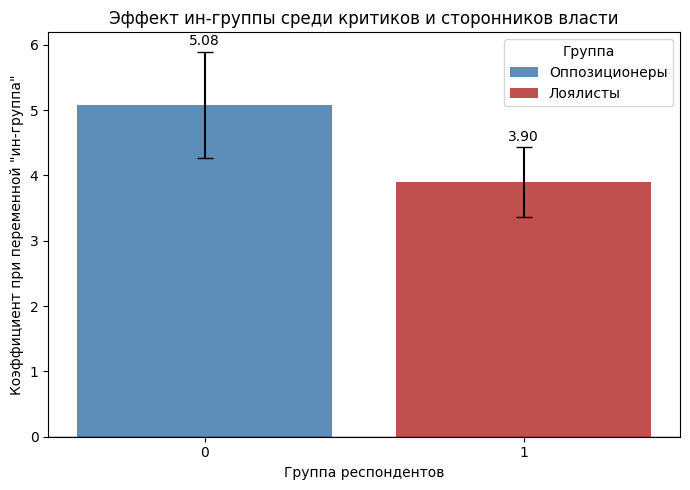

In [21]:
import matplotlib.pyplot as plt
import numpy as np

plot_df = h1_subgroup_results.copy()
plot_df = plot_df.sort_values("subgroup_value").reset_index(drop=True)

colors = {0: "#5B8DB8", 1: "#C0504D"}

label_map = {
    0: "Оппозиционеры",
    1: "Лоялисты"
}

x = np.arange(len(plot_df))
coef = plot_df["Ingroup"].to_numpy()

yerr_lower = coef - plot_df["ci_left"].to_numpy()
yerr_upper = plot_df["ci_right"].to_numpy() - coef

fig, ax = plt.subplots(figsize=(7, 5))

for i, row in plot_df.iterrows():
    group = int(row["subgroup_value"])

    ax.bar(
        i,
        row["Ingroup"],
        yerr=np.array([[row["Ingroup"] - row["ci_left"]],
                       [row["ci_right"] - row["Ingroup"]]]),
        capsize=6,
        color=colors[group],
        label=label_map[group]
    )

ax.axhline(0, color="black", linewidth=1)

ax.set_xticks(x)
# ax.set_xticklabels(["Критики власти", "Сторонники власти"])

ax.set_ylabel('Коэффициент при переменной "ин-группа"')
ax.set_xlabel("Группа респондентов")
ax.set_title("Эффект ин-группы среди критиков и сторонников власти")

ax.legend(title="Группа")

for i, value in enumerate(coef):
    ax.text(
        i,
        value + yerr_upper[i] + 0.05,
        f"{value:.2f}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

# Проверка на устойчивость с помощью порядковой лог регрессии

In [ ]:
import seaborn as sns

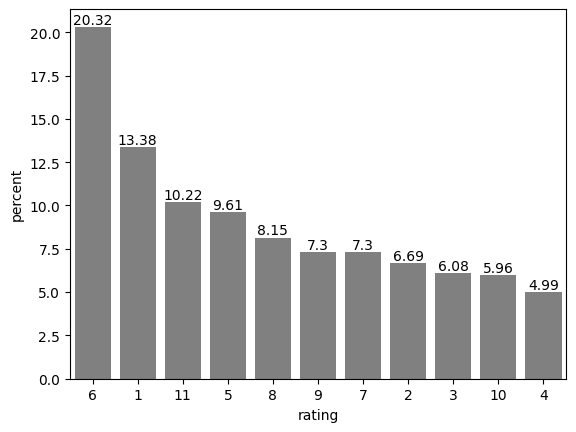

In [ ]:
distr = sns.countplot(x=long_h1['rating'], color = 'grey', stat = 'percent', order = long_h1['rating'].value_counts().index)
percent = long_h1['rating'].value_counts(ascending=False, normalize=True).values * 100
distr.bar_label(container=distr.containers[0], labels=np.round(percent,2));

In [ ]:
m1_ologit = OrderedModel.from_formula(f"rating ~ ingroup + {covariats} + {soc_dem} +{cands}", data=long_h1, distr = 'logit').fit(cov_type = "HC3", method='bfgs')
print(m1_ologit.summary())

Optimization terminated successfully.
         Current function value: 2.045596
         Iterations: 70
         Function evaluations: 74
         Gradient evaluations: 74
                             OrderedModel Results                             
Dep. Variable:                 rating   Log-Likelihood:                -1681.5
Model:                   OrderedModel   AIC:                             3419.
Method:            Maximum Likelihood   BIC:                             3551.
Date:                Fri, 05 Jun 2026                                         
Time:                        01:24:36                                         
No. Observations:                 822                                         
Df Residuals:                     794                                         
Df Model:                          18                                         
                         coef    std err          z      P>|z|      [0.025      0.975]
------------------------------

In [ ]:
np.exp(m1_ologit.params['ingroup'])

np.float64(17.101607388132134)

# **H2**

H2a: При не совпадении политической позиции респондента и кандидата из политической ин-группы уровень аффективной поляризации снижается

H2b: При совпадении политической позиции респондента и кандидата из политической аут-группы уровень аффективной поляризации снижается

## подтвердилось все

In [22]:
pair["h2_condition"] = pd.Series(pd.NA, index=pair.index, dtype="object")

is_nopos = pair["topic"].eq("nopos")
has_issue = pair["topic"].isin(["P", "E"])
pair.loc[is_nopos, "h2_condition"] = "nopos"
pair.loc[has_issue & pair["issue_match_ingroup"].eq(1) & pair["issue_match_outgroup"].eq(0),  "h2_condition"] = "in_match_out_mismatch"
pair.loc[has_issue & pair["issue_match_ingroup"].eq(1) & pair["issue_match_outgroup"].eq(1),"h2_condition"] = "both_match"
pair.loc[has_issue & pair["issue_match_ingroup"].eq(0) & pair["issue_match_outgroup"].eq(0), "h2_condition"] = "both_mismatch"
pair.loc[has_issue & pair["issue_match_ingroup"].eq(0) & pair["issue_match_outgroup"].eq(1), "h2_condition"] = "in_mismatch_out_match"

print(pair["h2_condition"].value_counts(dropna=False))

h2_condition
in_match_out_mismatch    422
both_mismatch            394
both_match               393
in_mismatch_out_match    391
<NA>                     374
nopos                    329
Name: count, dtype: int64


In [23]:
pair.dropna(subset = ['h2_condition'])

,Unnamed: 0,rid,interesta,identa,identb,trust,pol_talks_online,outgroup_contacts,outgroup_pol_talks,pol_talks,...,gender_outgroup,gender_ingroup,same_gender_pair,rating_ingroup,rating_outgroup,ap,issue_match_ingroup,issue_match_outgroup,resp_issue_importance,h2_condition
3,3,1,4,5,2,5.500000,1,3,3,3,...,мужчина,мужчина,1,6,6,0,NaN,NaN,NaN,nopos
4,4,1,4,5,2,5.500000,1,3,3,3,...,женщина,мужчина,0,3,11,-8,0.0,1.0,6.0,in_mismatch_out_match
5,5,1,4,5,2,5.500000,1,3,3,3,...,мужчина,мужчина,1,8,4,4,1.0,0.0,6.0,in_match_out_mismatch
6,6,1,4,5,2,5.500000,1,3,3,3,...,мужчина,мужчина,1,7,5,2,1.0,1.0,6.0,both_match
11,11,2,4,1,7,1.000000,1,5,1,1,...,женщина,мужчина,0,11,2,9,NaN,NaN,NaN,nopos
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2294,2294,328,6,7,2,7.000000,7,7,7,7,...,мужчина,женщина,0,8,1,7,0.0,1.0,6.0,in_mismatch_out_match
2295,2295,328,6,7,2,7.000000,7,7,7,7,...,женщина,женщина,1,8,1,7,1.0,1.0,6.0,both_match
2300,2300,329,7,1,7,1.666667,1,4,4,4,...,мужчина,мужчина,1,11,1,10,NaN,NaN,NaN,nopos
2301,2301,329,7,1,7,1.666667,1,4,4,4,...,женщина,женщина,1,11,5,6,1.0,1.0,1.0,both_match


In [24]:
h2 = pair.dropna(subset = ['h2_condition'])
print(h2["h2_condition"].value_counts(dropna=False))

h2_condition
in_match_out_mismatch    422
both_mismatch            394
both_match               393
in_mismatch_out_match    391
nopos                    329
Name: count, dtype: int64


In [25]:
m_h2_base = smf.ols('ap ~ C(h2_condition, Treatment(reference="nopos"))', data=h2).fit(cov_type="cluster", cov_kwds={"groups": h2["rid"]})
print(m_h2_base.summary())

                            OLS Regression Results                            
Dep. Variable:                     ap   R-squared:                       0.138
Model:                            OLS   Adj. R-squared:                  0.136
Method:                 Least Squares   F-statistic:                     73.72
Date:                Sun, 14 Jun 2026   Prob (F-statistic):           1.65e-44
Time:                        16:37:22   Log-Likelihood:                -5204.4
No. Observations:                1929   AIC:                         1.042e+04
Df Residuals:                    1924   BIC:                         1.045e+04
Df Model:                           4                                         
Covariance Type:              cluster                                         
                                                                             coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------

In [26]:
m_h2_cov= smf.ols(f'ap ~ C(h2_condition, Treatment(reference="nopos"))  + {covariats}', data=h2).fit(cov_type="cluster", cov_kwds={"groups": h2["rid"]})
print(m_h2_cov.summary())

                            OLS Regression Results                            
Dep. Variable:                     ap   R-squared:                       0.185
Model:                            OLS   Adj. R-squared:                  0.180
Method:                 Least Squares   F-statistic:                     30.70
Date:                Sun, 14 Jun 2026   Prob (F-statistic):           3.51e-44
Time:                        16:38:12   Log-Likelihood:                -5150.5
No. Observations:                1929   AIC:                         1.032e+04
Df Residuals:                    1917   BIC:                         1.039e+04
Df Model:                          11                                         
Covariance Type:              cluster                                         
                                                                             coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------

In [27]:
m_h2_soc= smf.ols(f'ap ~ C(h2_condition, Treatment(reference="nopos"))  + {soc_dem}', data=h2).fit(cov_type="cluster", cov_kwds={"groups": h2["rid"]})
print(m_h2_soc.summary())

                            OLS Regression Results                            
Dep. Variable:                     ap   R-squared:                       0.160
Model:                            OLS   Adj. R-squared:                  0.154
Method:                 Least Squares   F-statistic:                     26.67
Date:                Sun, 14 Jun 2026   Prob (F-statistic):           1.03e-41
Time:                        16:38:32   Log-Likelihood:                -5179.4
No. Observations:                1929   AIC:                         1.038e+04
Df Residuals:                    1916   BIC:                         1.046e+04
Df Model:                          12                                         
Covariance Type:              cluster                                         
                                                                             coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------

In [28]:
m_h2_full= smf.ols(f'ap ~ C(h2_condition, Treatment(reference="nopos"))  + {soc_dem} + {covariats}', data=h2).fit(cov_type="cluster", cov_kwds={"groups": h2["rid"]})
print(m_h2_full.summary())

                            OLS Regression Results                            
Dep. Variable:                     ap   R-squared:                       0.206
Model:                            OLS   Adj. R-squared:                  0.198
Method:                 Least Squares   F-statistic:                     19.67
Date:                Sun, 14 Jun 2026   Prob (F-statistic):           2.37e-43
Time:                        16:39:17   Log-Likelihood:                -5124.7
No. Observations:                1929   AIC:                         1.029e+04
Df Residuals:                    1909   BIC:                         1.040e+04
Df Model:                          19                                         
Covariance Type:              cluster                                         
                                                                             coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------

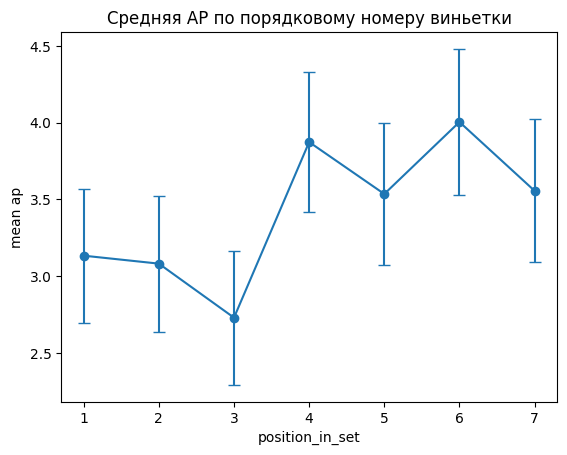

(np.float64(2.6774258798542805), np.float64(0.02030139102337298), np.float64(5.0))


In [29]:
# смотрим, как меняется среднее значение АП в зависимости от номера виньетки
diag = h2.groupby("position_in_set")["ap"].agg(["mean", "sem"]).reset_index()

plt.errorbar(diag["position_in_set"], diag["mean"],
             yerr=1.96*diag["sem"], fmt='o-', capsize=4)
plt.xlabel("position_in_set")
plt.ylabel("mean ap")
plt.title("Средняя AP по порядковому номеру виньетки")
plt.show()

m_lin = smf.ols('ap ~ position_in_set', data=h2).fit()
m_cat = smf.ols('ap ~ C(position_in_set)', data=h2).fit()

from scipy.stats import f as f_dist
print(m_cat.compare_f_test(m_lin))

In [30]:
# какие темы попадают на каждую позицию
h2.groupby(["position_in_set", "topic"]).size().unstack(fill_value=0)

topic,E,P,nopos
position_in_set,,,
1,177,53,32
2,82,187,0
3,97,156,25
4,76,115,108
5,98,173,0
6,66,112,102
7,129,79,62


In [31]:
# как распределены условия трит­мента по позициям
h2.groupby(["position_in_set", "h2_condition"]).size().unstack(fill_value=0)

h2_condition,both_match,both_mismatch,in_match_out_mismatch,in_mismatch_out_match,nopos
position_in_set,,,,,
1,36,71,49,74,32
2,87,84,48,50,0
3,55,100,29,69,25
4,58,19,69,45,108
5,56,27,117,71,0
6,34,39,64,41,102
7,67,54,46,41,62


position_in_set вообще не нужно включать как контроль порядка, т.к.  она не измеряет порядковый эффект в чистом виде, она смешана с составом виньеток. включение её в модель с взаимодействием не контролирует усталость, а вносит шум.

In [ ]:
h2['set_id']

,set_id
3,2
4,2
5,2
6,2
10,3
...,...
2868,3
2869,3
2874,5
2875,5


In [34]:
m_h2_itog= smf.ols(f'ap ~ C(h2_condition, Treatment(reference="nopos")) + {soc_dem} + {covariats} + {cands}', data=h2).fit(cov_type="cluster", cov_kwds={"groups": h2["rid"]})
print(m_h2_itog.summary())

                            OLS Regression Results                            
Dep. Variable:                     ap   R-squared:                       0.208
Model:                            OLS   Adj. R-squared:                  0.199
Method:                 Least Squares   F-statistic:                     18.12
Date:                Sun, 14 Jun 2026   Prob (F-statistic):           5.34e-43
Time:                        16:40:18   Log-Likelihood:                -5122.3
No. Observations:                1929   AIC:                         1.029e+04
Df Residuals:                    1907   BIC:                         1.041e+04
Df Model:                          21                                         
Covariance Type:              cluster                                         
                                                                             coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------

In [32]:
# теперь по support_bin
h2_subgroup_results1 = []


for group_value in sorted(h2["support_bin"].dropna().unique()):
    data_sub = h2[h2["support_bin"] == group_value].copy()

    m_sub = smf.ols(
        f'ap ~ C(h2_condition, Treatment(reference="nopos")) + {soc_dem} + {covariats} + {cands}',
        data=data_sub
    ).fit(
        cov_type='cluster',
        cov_kwds={'groups': data_sub['rid']}
    )

    print(group_value)

    print(m_sub.summary())
    print('\n\n\n')

    h2_subgroup_results1.append({
        "subgroup_var": "support_bin",
        "subgroup_value": group_value,
        "both_match": m_sub.params['C(h2_condition, Treatment(reference="nopos"))[T.both_match]'],
        # "se_ingroup": m_sub.bse["ingroup"],
        # "z": m_sub.tvalues["ingroup"],
        # "p": m_sub.pvalues["C(h2_condition, Treatment(reference="nopos"))[T.both_match]"],
        "ci_left": m_sub.conf_int()[0]['C(h2_condition, Treatment(reference="nopos"))[T.both_match]'],
        "ci_right": m_sub.conf_int()[1]['C(h2_condition, Treatment(reference="nopos"))[T.both_match]'],
        "n": int(m_sub.nobs),
        "n_clusters": data_sub["rid"].nunique()

    })

# print(pd.DataFrame(h2_subgroup_results))


0
                            OLS Regression Results                            
Dep. Variable:                     ap   R-squared:                       0.325
Model:                            OLS   Adj. R-squared:                  0.302
Method:                 Least Squares   F-statistic:                     10.76
Date:                Sun, 14 Jun 2026   Prob (F-statistic):           5.33e-18
Time:                        16:40:00   Log-Likelihood:                -1643.4
No. Observations:                 640   AIC:                             3331.
Df Residuals:                     618   BIC:                             3429.
Df Model:                          21                                         
Covariance Type:              cluster                                         
                                                                             coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------

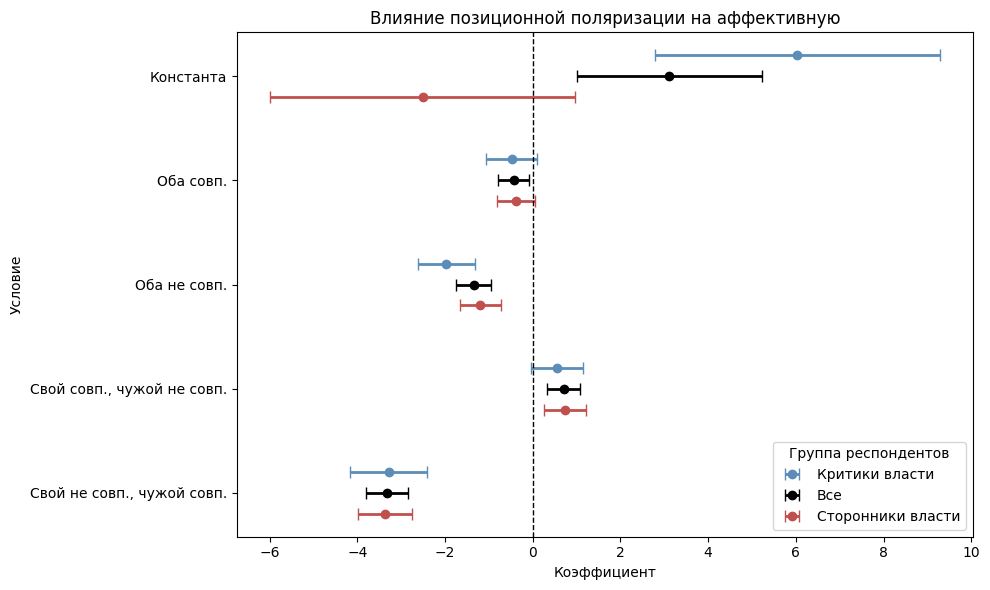

In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf

colors = {
    0: "#5B8DB8",
    1: "#C0504D",
    "all": "black"
}


group_labels = {
    0: "Критики власти",
    1: "Сторонники власти",
    "all": "Все"
}


terms = {
    "Intercept": "intercept",
    'C(h2_condition, Treatment(reference="nopos"))[T.both_match]': "both_match",
    'C(h2_condition, Treatment(reference="nopos"))[T.both_mismatch]': "both_mismatch",
    'C(h2_condition, Treatment(reference="nopos"))[T.in_match_out_mismatch]': "in_match_out_mismatch",
    'C(h2_condition, Treatment(reference="nopos"))[T.in_mismatch_out_match]': "in_mismatch_out_match"
}


term_order = [
    "intercept",
    "both_match",
    "both_mismatch",
    "in_match_out_mismatch",
    "in_mismatch_out_match"
]


term_labels_ru = {
    "intercept": "Константа",
    "both_match": "Оба совп.",
    "both_mismatch": "Оба не совп.",
    "in_match_out_mismatch": "Свой совп., чужой не совп.",
    "in_mismatch_out_match": "Свой не совп., чужой совп."
}


plot_rows = []


for group_value in sorted(h2["support_bin"].dropna().unique()):
    data_sub = h2[h2["support_bin"] == group_value].copy()

    m_sub = smf.ols(
        f'ap ~ C(h2_condition, Treatment(reference="nopos")) + {soc_dem} + {covariats} + {cands}',
        data=data_sub
    ).fit(
        cov_type="cluster",
        cov_kwds={"groups": data_sub["rid"]}
    )

    ci = m_sub.conf_int()

    for term_name, term_short in terms.items():
        if term_name in m_sub.params.index:
            plot_rows.append({
                "group": int(group_value),
                "group_label": group_labels[int(group_value)],
                "term": term_short,
                "coef": m_sub.params[term_name],
                "ci_left": ci.loc[term_name, 0],
                "ci_right": ci.loc[term_name, 1]
            })


ci_all = m_h2_itog.conf_int()

for term_name, term_short in terms.items():
    if term_name in m_h2_itog.params.index:
        plot_rows.append({
            "group": "all",
            "group_label": group_labels["all"],
            "term": term_short,
            "coef": m_h2_itog.params[term_name],
            "ci_left": ci_all.loc[term_name, 0],
            "ci_right": ci_all.loc[term_name, 1]
        })


plot_df = pd.DataFrame(plot_rows)

plot_df["term"] = pd.Categorical(
    plot_df["term"],
    categories=term_order,
    ordered=True
)


y_base = np.arange(len(term_order))
y_map = {term: i for i, term in enumerate(term_order)}


offsets = {
    0: -0.20,
    "all": 0.00,
    1: 0.20
}


fig, ax = plt.subplots(figsize=(10, 6))

for group_value in [0, "all", 1]:
    df_g = plot_df[plot_df["group"] == group_value].copy()
    df_g = df_g.sort_values("term")

    y = df_g["term"].map(y_map).astype(float).to_numpy()
    y = y + offsets[group_value]

    coef = df_g["coef"].to_numpy()

    xerr = np.vstack([
        coef - df_g["ci_left"].to_numpy(),
        df_g["ci_right"].to_numpy() - coef
    ])

    ax.errorbar(
        coef,
        y,
        xerr=xerr,
        fmt="o",
        capsize=4,
        linewidth=2,
        markersize=6,
        color=colors[group_value],
        label=group_labels[group_value]
    )


ax.axvline(0, color="black", linewidth=1, linestyle="--")


ax.set_yticks(y_base)
ax.set_yticklabels([term_labels_ru[t] for t in term_order])

ax.set_xlabel("Коэффициент")
ax.set_ylabel("Условие")
ax.set_title("Влияние позиционной поляризации на аффективную")


ax.legend(title="Группа респондентов")


ax.invert_yaxis()

plt.tight_layout()
plt.show()

In [ ]:
from stargazer.stargazer import Stargazer

sg = Stargazer([m_h2_base, m_h2_soc, m_h2_cov, m_h2_itog])

sg.title('Эффект позиционной поляризации на аффективную поляризацию')
# sg.custom_columns(['Парная', 'С контролями', 'Full controls + Deck FE'], [1, 1, 1])

sg.covariate_order([
    'C(h2_condition, Treatment(reference="nopos"))[T.both_match]',
    'C(h2_condition, Treatment(reference="nopos"))[T.both_mismatch]',
    'C(h2_condition, Treatment(reference="nopos"))[T.in_match_out_mismatch]',
    'C(h2_condition, Treatment(reference="nopos"))[T.in_mismatch_out_match]',
     'Intercept',
])



sg.rename_covariates({
    'C(h2_condition, Treatment(reference="nopos"))[T.both_match]':            'Both match',
    'C(h2_condition, Treatment(reference="nopos"))[T.both_mismatch]':         'Both mismatch',
    'C(h2_condition, Treatment(reference="nopos"))[T.in_match_out_mismatch]': 'In-match / Out-mismatch',
    'C(h2_condition, Treatment(reference="nopos"))[T.in_mismatch_out_match]': 'In-mismatch / Out-match',
    'position_in_set': 'Vignette position',
})

sg.add_line('Sociodemographic controls', ['', '$\\checkmark$', '', '$\\checkmark$'])
sg.add_line('Political controls',        ['', '', '$\\checkmark$', '$\\checkmark$'])
sg.add_line('Пол и возраст кандидатов',        ['', '', '', '$\\checkmark$'])

print(sg.render_latex())

\begin{table}[!htbp] \centering
  \caption{Эффект позиционной поляризации на аффективную поляризацию}
\begin{tabular}{@{\extracolsep{5pt}}lcccc}
\\[-1.8ex]\hline
\hline \\[-1.8ex]
& \multicolumn{4}{c}{\textit{Dependent variable: ap}} \
\cr \cline{2-5}
\\[-1.8ex] & (1) & (2) & (3) & (4) \\
\hline \\[-1.8ex]
 Both match & -0.401$^{**}$ & -0.439$^{**}$ & -0.443$^{**}$ & -0.439$^{**}$ \\
& (0.181) & (0.179) & (0.179) & (0.181) \\
 Both mismatch & -1.332$^{***}$ & -1.352$^{***}$ & -1.315$^{***}$ & -1.349$^{***}$ \\
& (0.201) & (0.200) & (0.198) & (0.199) \\
 In-match / Out-mismatch & 0.775$^{***}$ & 0.756$^{***}$ & 0.717$^{***}$ & 0.703$^{***}$ \\
& (0.191) & (0.190) & (0.188) & (0.193) \\
 In-mismatch / Out-match & -3.355$^{***}$ & -3.353$^{***}$ & -3.300$^{***}$ & -3.321$^{***}$ \\
& (0.238) & (0.240) & (0.239) & (0.248) \\
 Intercept & 4.289$^{***}$ & 3.420$^{***}$ & 3.113$^{***}$ & 3.108$^{***}$ \\
& (0.225) & (0.959) & (0.639) & (1.077) \\
 Sociodemographic controls &  & $\checkmark$ &

Теперь проверим механизмы изменения аффективной поляризации: понижается оценка своего или повышается оценка чужого

In [46]:
# КАК СОВПАДЕНИЯ И НЕ СОВПАДЕНИЯ ВЛИЯЮТ НА ОЦЕНКУ ИН-ГРУППОВОГО КАНДИДАТА
m_h2_itog_ingroup= smf.ols(f'rating_ingroup ~  C(h2_condition, Treatment(reference="nopos")) + {soc_dem} + {covariats} + {cands}', data=h2).fit(cov_type="cluster", cov_kwds={"groups": h2["rid"]})
print(m_h2_itog_ingroup.summary())

                            OLS Regression Results                            
Dep. Variable:         rating_ingroup   R-squared:                       0.215
Model:                            OLS   Adj. R-squared:                  0.206
Method:                 Least Squares   F-statistic:                     17.75
Date:                Sun, 14 Jun 2026   Prob (F-statistic):           2.94e-42
Time:                        16:47:00   Log-Likelihood:                -4345.2
No. Observations:                1929   AIC:                             8734.
Df Residuals:                    1907   BIC:                             8857.
Df Model:                          21                                         
Covariance Type:              cluster                                         
                                                                             coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------

In [44]:
hypothesis = 'C(h2_condition, Treatment(reference="nopos"))[T.both_match]    = C(h2_condition, Treatment(reference="nopos"))[T.in_match_out_mismatch] '
wald_test = m_h2_itog_ingroup.wald_test(hypothesis)

print(wald_test)

<Wald test (chi2): statistic=[[0.431983]], p-value=0.5110175194592705, df_denom=1>


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:1912: FutureWarning: The behavior of wald_test will change after 0.14 to returning scalar test statistic values. To get the future behavior now, set scalar to True. To silence this message while retaining the legacy behavior, set scalar to False.
  warnings.warn(


In [47]:
# КАК СОВПАДЕНИЯ И НЕ СОВПАДЕНИЯ ВЛИЯЮТ НА ОЦЕНКУ АУТ-ГРУППОВОГО КАНДИДАТА
m_h2_full_outgroup = smf.ols(f'rating_outgroup ~ C(h2_condition, Treatment(reference="nopos")) + {soc_dem} + {covariats} + {cands}', data=h2).fit(cov_type="cluster", cov_kwds={"groups": h2["rid"]})
print(m_h2_full_outgroup.summary())

                            OLS Regression Results                            
Dep. Variable:        rating_outgroup   R-squared:                       0.183
Model:                            OLS   Adj. R-squared:                  0.174
Method:                 Least Squares   F-statistic:                     14.93
Date:                Sun, 14 Jun 2026   Prob (F-statistic):           2.58e-36
Time:                        16:48:17   Log-Likelihood:                -4222.5
No. Observations:                1929   AIC:                             8489.
Df Residuals:                    1907   BIC:                             8611.
Df Model:                          21                                         
Covariance Type:              cluster                                         
                                                                             coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------

In [45]:
hypothesis = 'C(h2_condition, Treatment(reference="nopos"))[T.in_match_out_mismatch]  = C(h2_condition, Treatment(reference="nopos"))[T.both_mismatch]'
wald_test = m_h2_full_outgroup.wald_test(hypothesis)

print(wald_test)

<Wald test (chi2): statistic=[[0.00413695]], p-value=0.9487160957134712, df_denom=1>


In [43]:
sg = Stargazer([m_h2_itog_ingroup, m_h2_full_outgroup])

sg.title('Эффект позиционной поляризации на оценки кандидатов')
sg.custom_columns(['Ин-группа', 'Аут-группа'], [1, 1])

sg.covariate_order([
    'C(h2_condition, Treatment(reference="nopos"))[T.both_match]',
    'C(h2_condition, Treatment(reference="nopos"))[T.both_mismatch]',
    'C(h2_condition, Treatment(reference="nopos"))[T.in_match_out_mismatch]',
    'C(h2_condition, Treatment(reference="nopos"))[T.in_mismatch_out_match]',
     'Intercept',
])



sg.rename_covariates({
    'C(h2_condition, Treatment(reference="nopos"))[T.both_match]':            'Both match',
    'C(h2_condition, Treatment(reference="nopos"))[T.both_mismatch]':         'Both mismatch',
    'C(h2_condition, Treatment(reference="nopos"))[T.in_match_out_mismatch]': 'In-match / Out-mismatch',
    'C(h2_condition, Treatment(reference="nopos"))[T.in_mismatch_out_match]': 'In-mismatch / Out-match',
    'position_in_set': 'Vignette position',
})

sg.add_line('Sociodemographic controls', ['$\\checkmark$', '$\\checkmark$'])
sg.add_line('Political controls',        ['$\\checkmark$', '$\\checkmark$'])
sg.add_line('Пол и возраст кандидата',        ['$\\checkmark$', '$\\checkmark$'])

print(sg.render_latex())

\begin{table}[!htbp] \centering
  \caption{Эффект позиционной поляризации на оценки кандидатов}
\begin{tabular}{@{\extracolsep{5pt}}lcc}
\\[-1.8ex]\hline
\hline \\[-1.8ex]
\\[-1.8ex] & \multicolumn{1}{c}{Ин-группа} & \multicolumn{1}{c}{Аут-группа}  \\
\\[-1.8ex] & (1) & (2) \\
\hline \\[-1.8ex]
 Both match & 0.179$^{}$ & 0.729$^{***}$ \\
& (0.235) & (0.208) \\
 Both mismatch & -2.055$^{***}$ & -0.237$^{}$ \\
& (0.267) & (0.173) \\
 In-match / Out-mismatch & 0.336$^{}$ & -0.226$^{}$ \\
& (0.206) & (0.164) \\
 In-mismatch / Out-match & -2.199$^{***}$ & 1.147$^{***}$ \\
& (0.283) & (0.230) \\
 Intercept & 7.078$^{***}$ & 4.004$^{***}$ \\
& (0.713) & (0.742) \\
 Sociodemographic controls & $\checkmark$ & $\checkmark$ \\
 Political controls & $\checkmark$ & $\checkmark$ \\
 Пол и возраст кандидата & $\checkmark$ & $\checkmark$ \\
\hline \\[-1.8ex]
 Observations & 1929 & 1929 \\
 $R^2$ & 0.219 & 0.195 \\
 Adjusted $R^2$ & 0.208 & 0.184 \\
 Residual Std. Error & 2.311 (df=1902) & 2.158 (df=19

In [48]:
m_h2_itog_ingroup= smf.ols(f'rating_ingroup ~  C(h2_condition, Treatment(reference="nopos"))*support_bin + {soc_dem} + {covariats} + {cands}', data=h2).fit(cov_type="cluster", cov_kwds={"groups": h2["rid"]})


m_h2_full_outgroup = smf.ols(f'rating_outgroup ~ C(h2_condition, Treatment(reference="nopos"))*support_bin + {soc_dem} + {covariats} + {cands}', data=h2).fit(cov_type="cluster", cov_kwds={"groups": h2["rid"]})


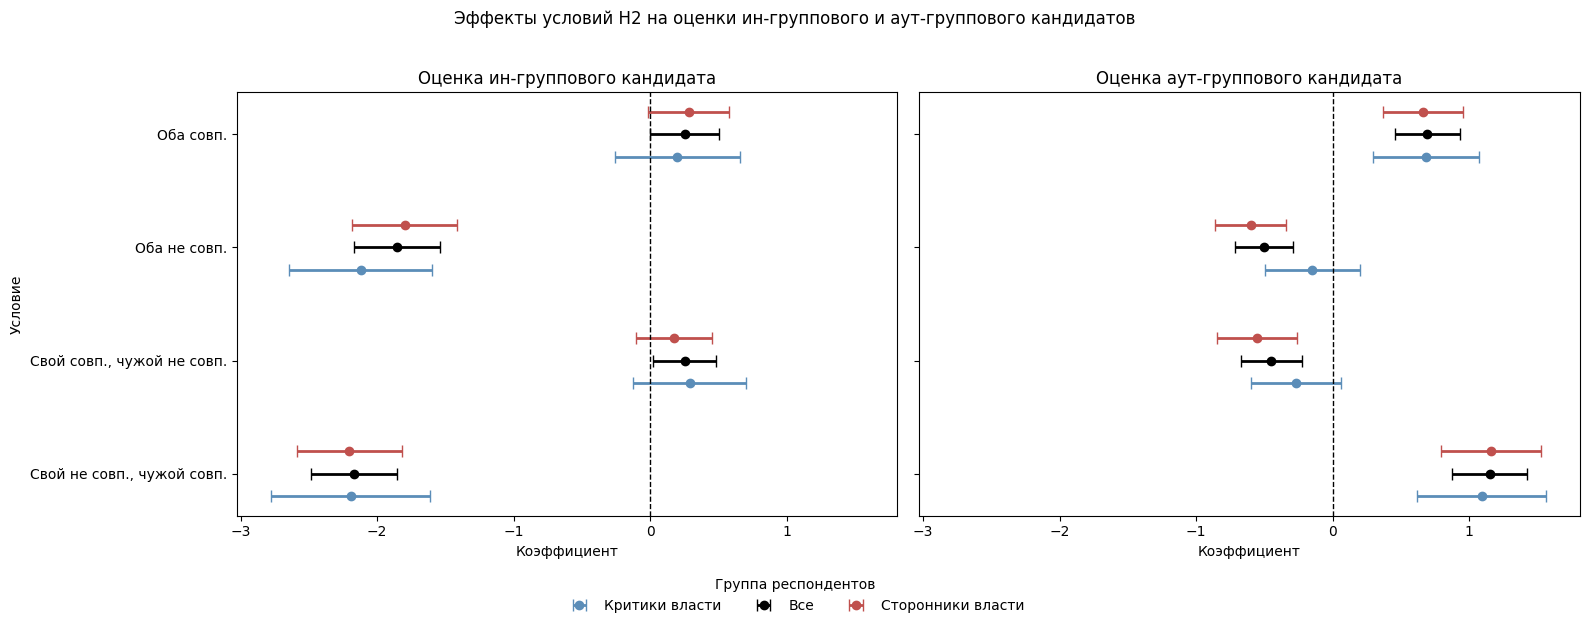

In [49]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf


colors = {
    0: "#5B8DB8",
    1: "#C0504D",
    "all": "black"
}


group_labels = {
    0: "Критики власти",
    1: "Сторонники власти",
    "all": "Все"
}


terms = {
    'C(h2_condition, Treatment(reference="nopos"))[T.both_match]': "both_match",
    'C(h2_condition, Treatment(reference="nopos"))[T.both_mismatch]': "both_mismatch",
    'C(h2_condition, Treatment(reference="nopos"))[T.in_match_out_mismatch]': "in_match_out_mismatch",
    'C(h2_condition, Treatment(reference="nopos"))[T.in_mismatch_out_match]': "in_mismatch_out_match"
}


term_order = [
    "in_mismatch_out_match",
    "in_match_out_mismatch",
    "both_mismatch",
    "both_match"
]


term_labels_ru = {
    "both_match": "Оба совп.",
    "both_mismatch": "Оба не совп.",
    "in_match_out_mismatch": "Свой совп., чужой не совп.",
    "in_mismatch_out_match": "Свой не совп., чужой совп."
}


offsets = {
    0: -0.20,
    "all": 0.00,
    1: 0.20
}


def collect_model_results(dep_var):

    formula = (
        f'{dep_var} ~ C(h2_condition, Treatment(reference="nopos")) '
        f'+ {soc_dem} + {covariats} + {cands}'
    )

    plot_rows = []


    for group_value in sorted(h2["support_bin"].dropna().unique()):
        data_sub = h2[h2["support_bin"] == group_value].copy()

        m_sub = smf.ols(
            formula,
            data=data_sub
        ).fit(
            cov_type="cluster",
            cov_kwds={"groups": data_sub["rid"]}
        )

        ci = m_sub.conf_int()

        for term_name, term_short in terms.items():
            if term_name in m_sub.params.index:
                plot_rows.append({
                    "dep_var": dep_var,
                    "group": int(group_value),
                    "group_label": group_labels[int(group_value)],
                    "term": term_short,
                    "coef": m_sub.params[term_name],
                    "ci_left": ci.loc[term_name, 0],
                    "ci_right": ci.loc[term_name, 1],
                    "n": int(m_sub.nobs),
                    "n_clusters": data_sub["rid"].nunique()
                })


    m_all = smf.ols(
        formula,
        data=h2
    ).fit(
        cov_type="cluster",
        cov_kwds={"groups": h2["rid"]}
    )

    ci_all = m_all.conf_int()

    for term_name, term_short in terms.items():
        if term_name in m_all.params.index:
            plot_rows.append({
                "dep_var": dep_var,
                "group": "all",
                "group_label": group_labels["all"],
                "term": term_short,
                "coef": m_all.params[term_name],
                "ci_left": ci_all.loc[term_name, 0],
                "ci_right": ci_all.loc[term_name, 1],
                "n": int(m_all.nobs),
                "n_clusters": h2["rid"].nunique()
            })

    plot_df = pd.DataFrame(plot_rows)

    plot_df["term"] = pd.Categorical(
        plot_df["term"],
        categories=term_order,
        ordered=True
    )

    return plot_df


def draw_coef_plot(ax, plot_df, title, show_ylabel=True):


    y_base = np.arange(len(term_order))
    y_map = {term: i for i, term in enumerate(term_order)}

    for group_value in [0, "all", 1]:
        df_g = plot_df[plot_df["group"] == group_value].copy()
        df_g = df_g.sort_values("term")

        y = df_g["term"].map(y_map).astype(float).to_numpy()
        y = y + offsets[group_value]

        coef = df_g["coef"].to_numpy()

        xerr = np.vstack([
            coef - df_g["ci_left"].to_numpy(),
            df_g["ci_right"].to_numpy() - coef
        ])

        ax.errorbar(
            coef,
            y,
            xerr=xerr,
            fmt="o",
            capsize=4,
            linewidth=2,
            markersize=6,
            color=colors[group_value],
            label=group_labels[group_value]
        )



    ax.axvline(0, color="black", linewidth=1, linestyle="--")

    ax.set_yticks(y_base)
    ax.set_yticklabels([term_labels_ru[t] for t in term_order])

    ax.set_xlabel("Коэффициент")
    ax.set_title(title)

    if show_ylabel:
        ax.set_ylabel("Условие")
    else:
        ax.set_ylabel("")

    # ax.invert_yaxis()


plot_df_ingroup = collect_model_results("rating_ingroup")
plot_df_outgroup = collect_model_results("rating_outgroup")

combined = pd.concat([plot_df_ingroup, plot_df_outgroup], ignore_index=True)

x_min = combined["ci_left"].min()
x_max = combined["ci_right"].max()
padding = 0.25


fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

draw_coef_plot(
    axes[0],
    plot_df_ingroup,
    "Оценка ин-группового кандидата",
    show_ylabel=True
)

draw_coef_plot(
    axes[1],
    plot_df_outgroup,
    "Оценка аут-группового кандидата",
    show_ylabel=False
)


for ax in axes:
    ax.set_xlim(x_min - padding, x_max + padding)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    title="Группа респондентов",
    loc="lower center",
    ncol=3,
    frameon=False
)

fig.suptitle("Эффекты условий H2 на оценки ин-группового и аут-группового кандидатов", y=1.02)

plt.tight_layout(rect=[0, 0.08, 1, 1])
plt.show()

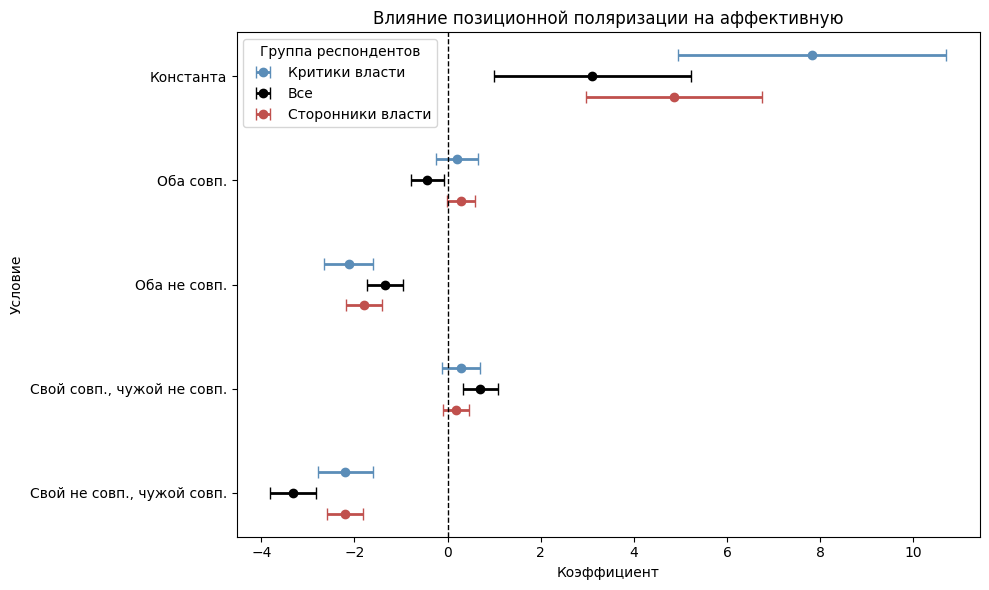

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf

colors = {
    0: "#5B8DB8",
    1: "#C0504D",
    "all": "black"
}


group_labels = {
    0: "Критики власти",
    1: "Сторонники власти",
    "all": "Все"
}

terms = {
    "Intercept": "intercept",
    'C(h2_condition, Treatment(reference="nopos"))[T.both_match]': "both_match",
    'C(h2_condition, Treatment(reference="nopos"))[T.both_mismatch]': "both_mismatch",
    'C(h2_condition, Treatment(reference="nopos"))[T.in_match_out_mismatch]': "in_match_out_mismatch",
    'C(h2_condition, Treatment(reference="nopos"))[T.in_mismatch_out_match]': "in_mismatch_out_match"
}


term_order = [
    "intercept",
    "both_match",
    "both_mismatch",
    "in_match_out_mismatch",
    "in_mismatch_out_match"
]

term_labels_ru = {
    "intercept": "Константа",
    "both_match": "Оба совп.",
    "both_mismatch": "Оба не совп.",
    "in_match_out_mismatch": "Свой совп., чужой не совп.",
    "in_mismatch_out_match": "Свой не совп., чужой совп."
}


plot_rows = []

for group_value in sorted(h2["support_bin"].dropna().unique()):
    data_sub = h2[h2["support_bin"] == group_value].copy()

    m_sub = smf.ols(
        f'rating_ingroup ~ C(h2_condition, Treatment(reference="nopos")) + {soc_dem} + {covariats} + {cands}',
        data=data_sub
    ).fit(
        cov_type="cluster",
        cov_kwds={"groups": data_sub["rid"]}
    )

    ci = m_sub.conf_int()

    for term_name, term_short in terms.items():
        if term_name in m_sub.params.index:
            plot_rows.append({
                "group": int(group_value),
                "group_label": group_labels[int(group_value)],
                "term": term_short,
                "coef": m_sub.params[term_name],
                "ci_left": ci.loc[term_name, 0],
                "ci_right": ci.loc[term_name, 1]
            })


ci_all = m_h2_itog.conf_int()

for term_name, term_short in terms.items():
    if term_name in m_h2_itog.params.index:
        plot_rows.append({
            "group": "all",
            "group_label": group_labels["all"],
            "term": term_short,
            "coef": m_h2_itog.params[term_name],
            "ci_left": ci_all.loc[term_name, 0],
            "ci_right": ci_all.loc[term_name, 1]
        })

plot_df = pd.DataFrame(plot_rows)

plot_df["term"] = pd.Categorical(
    plot_df["term"],
    categories=term_order,
    ordered=True
)

y_base = np.arange(len(term_order))
y_map = {term: i for i, term in enumerate(term_order)}


offsets = {
    0: -0.20,
    "all": 0.00,
    1: 0.20
}

fig, ax = plt.subplots(figsize=(10, 6))

for group_value in [0, "all", 1]:
    df_g = plot_df[plot_df["group"] == group_value].copy()
    df_g = df_g.sort_values("term")

    y = df_g["term"].map(y_map).astype(float).to_numpy()
    y = y + offsets[group_value]

    coef = df_g["coef"].to_numpy()

    xerr = np.vstack([
        coef - df_g["ci_left"].to_numpy(),
        df_g["ci_right"].to_numpy() - coef
    ])

    ax.errorbar(
        coef,
        y,
        xerr=xerr,
        fmt="o",
        capsize=4,
        linewidth=2,
        markersize=6,
        color=colors[group_value],
        label=group_labels[group_value]
    )

ax.axvline(0, color="black", linewidth=1, linestyle="--")


ax.set_yticks(y_base)
ax.set_yticklabels([term_labels_ru[t] for t in term_order])


ax.set_xlabel("Коэффициент")
ax.set_ylabel("Условие")
ax.set_title("Влияние позиционной поляризации на аффективную")


ax.legend(title="Группа респондентов")


ax.invert_yaxis()

plt.tight_layout()
plt.show()

# **H3**

Н3а: Не совпадение политической позиции респондента и кандидата из политической ин-группы по вопросам, связанным с расколом «лоялисты – оппозиционеры», сильнее сокращает уровень аффективной поляризации, чем по вопросам, не связанным с этим расколом

**ingroup_mismatch x topic_P < 0**


Н3б: Совпадение политической позиции респондента и кандидата из политической аут-группы по вопросам, связанным с расколом «лоялисты – оппозиционеры», сильнее сокращает уровень аффективной поляризации, чем по вопросам, не связанным с этим расколом

**outgroup_match x topic_P < 0**


 И ЭТИ ТОЖЕ ПОДТВЕРДИЛИСЬ


In [ ]:
h3.columns

Index(['Unnamed: 0', 'rid', 'interesta', 'identa', 'identb', 'trust',
       'pol_talks_online', 'outgroup_contacts', 'outgroup_pol_talks',
       'pol_talks', 'fed_tv', 'support_bin', 'patra', 'imppatra', 'euthana',
       'impeuthana', 'gender', 'age', 'educ', 'income', 'city', 'set_id',
       'position_in_set', 'var_name', 'vignette_code', 'topic', 'combo',
       'resp_issue_pos', 'age_outgroup', 'age_ingroup', 'age_gap',
       'gender_outgroup', 'gender_ingroup', 'same_gender_pair',
       'rating_ingroup', 'rating_outgroup', 'ap', 'issue_match_ingroup',
       'issue_match_outgroup', 'resp_issue_importance', 'h2_condition',
       'ingroup_mismatch', 'outgroup_match', 'topic_P'],
      dtype='object')

In [50]:
h3 = pair[pair["topic"].isin(["P", "E"])]

# H3a: несовпадение ин-группы
h3["ingroup_mismatch"] = 1 - h3["issue_match_ingroup"]

# H3b: совпадение аут-группы
h3["outgroup_match"] = h3["issue_match_outgroup"]

h3["topic_P"] = (h3["topic"] == "P").astype(int)

h3 = h3.dropna(subset = ['ingroup_mismatch', 'outgroup_match'])

print("N observations:", len(h3))
print("N respondents:", h3["rid"].nunique())

print("\nРаспределение тем:")
print(h3["topic"].value_counts())

print("\nСредний AP по условиям:")
h3.groupby(["topic", "ingroup_mismatch", "outgroup_match"])["ap"].agg(["count", "mean", "std"])

N observations: 1600
N respondents: 319

Распределение тем:
topic
P    875
E    725
Name: count, dtype: int64

Средний AP по условиям:


/tmp/ipykernel_726/2478736514.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  h3["ingroup_mismatch"] = 1 - h3["issue_match_ingroup"]
/tmp/ipykernel_726/2478736514.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  h3["outgroup_match"] = h3["issue_match_outgroup"]
/tmp/ipykernel_726/2478736514.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydat

count      mean       std
topic ingroup_mismatch outgroup_match                           
E     0.0              0.0               186  4.801075  3.742842
                       1.0               179  3.849162  3.302134
      1.0              0.0               178  3.044944  3.330768
                       1.0               182  1.401099  3.876348
P     0.0              0.0               236  5.271186  4.010966
                       1.0               214  3.920561  3.236855
      1.0              0.0               216  2.884259  2.993098
                       1.0               209  0.526316  3.250817

In [51]:
# баз.кат. - тема эвтаназия, ин-группа совпадает, аут-группа не совпадает.
m_h3_base = smf.ols('ap ~ ingroup_mismatch * topic_P + outgroup_match * topic_P + ingroup_mismatch * outgroup_match ', data=h3).fit(cov_type="cluster", cov_kwds={"groups": h3["rid"]})

print(m_h3_base.summary())

                            OLS Regression Results                            
Dep. Variable:                     ap   R-squared:                       0.163
Model:                            OLS   Adj. R-squared:                  0.160
Method:                 Least Squares   F-statistic:                     48.87
Date:                Sun, 14 Jun 2026   Prob (F-statistic):           2.28e-42
Time:                        16:56:44   Log-Likelihood:                -4264.7
No. Observations:                1600   AIC:                             8543.
Df Residuals:                    1593   BIC:                             8581.
Df Model:                           6                                         
Covariance Type:              cluster                                         
                                      coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------------
Intercept 

In [ ]:
m_h3_full = smf.ols(f"""
        ap ~ ingroup_mismatch * topic_P
         + outgroup_match * topic_P
         + {soc_dem}
         + {covariats}
         + {cands}
    """,
    data=h3
).fit(
    cov_type="cluster",
    cov_kwds={"groups": h3["rid"]}
)

print(m_h3_full.summary())

                            OLS Regression Results                            
Dep. Variable:                     ap   R-squared:                       0.227
Model:                            OLS   Adj. R-squared:                  0.216
Method:                 Least Squares   F-statistic:                     16.94
Date:                Tue, 09 Jun 2026   Prob (F-statistic):           2.45e-41
Time:                        23:32:10   Log-Likelihood:                -4201.5
No. Observations:                1600   AIC:                             8449.
Df Residuals:                    1577   BIC:                             8573.
Df Model:                          22                                         
Covariance Type:              cluster                                         
                               coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------
Intercept               

In [ ]:
# теперь по support_bin
h1_subgroup_results = []

for group_value in sorted(h3["support_bin"].dropna().unique()):
    data_sub = h3[h3["support_bin"] == group_value].copy()

    m_sub = smf.ols(f"""
        ap ~ ingroup_mismatch * topic_P
         + outgroup_match * topic_P
         + {soc_dem}
         + {covariats}
         + {cands}
    """,
        data=data_sub
    ).fit(
        cov_type='cluster',
        cov_kwds={'groups': data_sub['rid']}
    )

    h1_subgroup_results.append({
        "subgroup_var": "support_bin",
        "subgroup_value": group_value,
        "Ingroup": m_sub.params['outgroup_match:topic_P'],
        "se_ingroup": m_sub.bse['outgroup_match:topic_P'],
        "z": m_sub.tvalues['outgroup_match:topic_P'],
        "p": m_sub.pvalues['outgroup_match:topic_P'],
        "ci_left": m_sub.conf_int()[0]['outgroup_match:topic_P'],
        "ci_right": m_sub.conf_int()[1]['outgroup_match:topic_P'],
        "n": int(m_sub.nobs),
        "n_clusters": data_sub["rid"].nunique()

    })

h1_subgroup_results = pd.DataFrame(h1_subgroup_results)
h1_subgroup_results

,subgroup_var,subgroup_value,Ingroup,se_ingroup,z,p,ci_left,ci_right,n,n_clusters
0,support_bin,0,0.102313,0.370737,0.275972,0.782569,-0.624319,0.828945,531,105
1,support_bin,1,-0.733194,0.324306,-2.260810,0.023771,-1.368822,-0.097566,1069,214


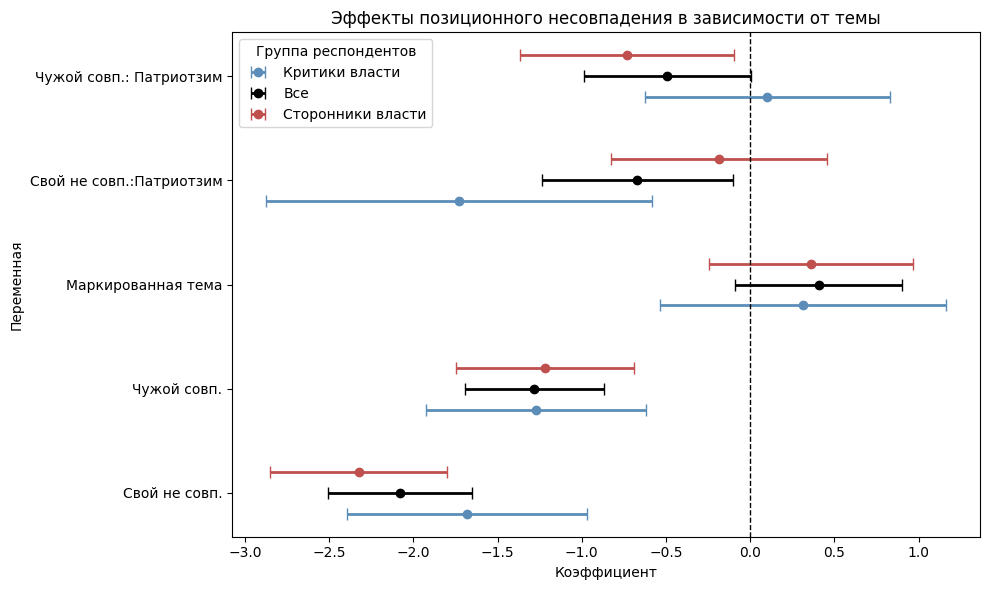

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf

colors = {
    0: "#5B8DB8",
    1: "#C0504D",
    "all": "black"
}


group_labels = {
    0: "Критики власти",
    1: "Сторонники власти",
    "all": "Все"
}

formula_h3 = f"""
    ap ~ ingroup_mismatch * topic_P
       + outgroup_match * topic_P
       + {soc_dem}
       + {covariats}
       + {cands}
"""

terms = {
    "ingroup_mismatch": "ingroup_mismatch",
    "outgroup_match": "outgroup_match",
    "topic_P": "topic_P",
    "ingroup_mismatch:topic_P": "ingroup_mismatch_topic_P",
    "outgroup_match:topic_P": "outgroup_match_topic_P"
}

term_order = [
    "ingroup_mismatch",
    "outgroup_match",
    "topic_P",
    "ingroup_mismatch_topic_P",
    "outgroup_match_topic_P"
]

term_labels_ru = {
    "ingroup_mismatch": "Свой не совп.",
    "outgroup_match": "Чужой совп.",
    "topic_P": "Маркированная тема",
    "ingroup_mismatch_topic_P": "Свой не совп.:Патриотзим",
    "outgroup_match_topic_P": "Чужой совп.: Патриотзим"
}

offsets = {
    0: -0.20,
    "all": 0.00,
    1: 0.20
}

plot_rows = []

for group_value in sorted(h3["support_bin"].dropna().unique()):
    data_sub = h3[h3["support_bin"] == group_value].copy()

    m_sub = smf.ols(
        formula_h3,
        data=data_sub
    ).fit(
        cov_type="cluster",
        cov_kwds={"groups": data_sub["rid"]}
    )

    ci = m_sub.conf_int()

    for term_name, term_short in terms.items():
        if term_name in m_sub.params.index:
            plot_rows.append({
                "group": int(group_value),
                "group_label": group_labels[int(group_value)],
                "term": term_short,
                "coef": m_sub.params[term_name],
                "ci_left": ci.loc[term_name, 0],
                "ci_right": ci.loc[term_name, 1],
                "p": m_sub.pvalues[term_name],
                "n": int(m_sub.nobs),
                "n_clusters": data_sub["rid"].nunique()
            })

ci_all = m_h3_full.conf_int()

for term_name, term_short in terms.items():
    if term_name in m_h3_full.params.index:
        plot_rows.append({
            "group": "all",
            "group_label": group_labels["all"],
            "term": term_short,
            "coef": m_h3_full.params[term_name],
            "ci_left": ci_all.loc[term_name, 0],
            "ci_right": ci_all.loc[term_name, 1],
            "p": m_h3_full.pvalues[term_name],
            "n": int(m_h3_full.nobs),
            "n_clusters": h3["rid"].nunique()
        })

plot_df_h3 = pd.DataFrame(plot_rows)

plot_df_h3["term"] = pd.Categorical(
    plot_df_h3["term"],
    categories=term_order,
    ordered=True
)

y_base = np.arange(len(term_order))
y_map = {term: i for i, term in enumerate(term_order)}

fig, ax = plt.subplots(figsize=(10, 6))

for group_value in [0, "all", 1]:
    df_g = plot_df_h3[plot_df_h3["group"] == group_value].copy()
    df_g = df_g.sort_values("term")

    y = df_g["term"].map(y_map).astype(float).to_numpy()
    y = y + offsets[group_value]

    coef = df_g["coef"].to_numpy()

    xerr = np.vstack([
        coef - df_g["ci_left"].to_numpy(),
        df_g["ci_right"].to_numpy() - coef
    ])

    ax.errorbar(
        coef,
        y,
        xerr=xerr,
        fmt="o",
        capsize=4,
        linewidth=2,
        markersize=6,
        color=colors[group_value],
        label=group_labels[group_value]
    )

ax.axvline(0, color="black", linewidth=1, linestyle="--")

ax.set_yticks(y_base)
ax.set_yticklabels([term_labels_ru[t] for t in term_order])

ax.set_xlabel("Коэффициент")
ax.set_ylabel("Переменная")
ax.set_title("Эффекты позиционного несовпадения в зависимости от темы")

ax.legend(title="Группа респондентов")

plt.tight_layout()
plt.show()

In [ ]:
sg = Stargazer([m_h3_base, m_h3_full])

sg.title('Эффект темы')
# sg.custom_columns(['Ин-группа', 'Аут-группа'], [1, 1])

sg.covariate_order([
    'ingroup_mismatch',
    'outgroup_match',
    'topic_P',
    'ingroup_mismatch:topic_P',
    'outgroup_match:topic_P',
    'ingroup_mismatch:outgroup_match',
     'Intercept',
])



# sg.rename_covariates({
#     'C(h2_condition, Treatment(reference="nopos"))[T.both_match]':            'Both match',
#     'C(h2_condition, Treatment(reference="nopos"))[T.both_mismatch]':         'Both mismatch',
#     'C(h2_condition, Treatment(reference="nopos"))[T.in_match_out_mismatch]': 'In-match / Out-mismatch',
#     'C(h2_condition, Treatment(reference="nopos"))[T.in_mismatch_out_match]': 'In-mismatch / Out-match',
#     'position_in_set': 'Vignette position',
# })

sg.add_line('Sociodemographic controls', ['', '$\\checkmark$'])
sg.add_line('Political controls',        ['', '$\\checkmark$'])
sg.add_line('Пол и возраст кандидата',        ['', '$\\checkmark$'])

print(sg.render_latex())

\begin{table}[!htbp] \centering
  \caption{Эффект темы}
\begin{tabular}{@{\extracolsep{5pt}}lcc}
\\[-1.8ex]\hline
\hline \\[-1.8ex]
& \multicolumn{2}{c}{\textit{Dependent variable: ap}} \
\cr \cline{2-3}
\\[-1.8ex] & (1) & (2) \\
\hline \\[-1.8ex]
 ingroup_mismatch & -1.670$^{***}$ & -1.665$^{***}$ \\
& (0.250) & (0.263) \\
 outgroup_match & -0.866$^{***}$ & -0.852$^{***}$ \\
& (0.248) & (0.262) \\
 topic_P & 0.545$^{**}$ & 0.460$^{*}$ \\
& (0.252) & (0.257) \\
 ingroup_mismatch:topic_P & -0.786$^{***}$ & -0.689$^{**}$ \\
& (0.299) & (0.288) \\
 outgroup_match:topic_P & -0.554$^{**}$ & -0.512$^{**}$ \\
& (0.261) & (0.254) \\
 ingroup_mismatch:outgroup_match & -0.864$^{***}$ & -0.851$^{**}$ \\
& (0.283) & (0.350) \\
 Intercept & 4.759$^{***}$ & 3.596$^{***}$ \\
& (0.268) & (1.089) \\
 Sociodemographic controls &  & $\checkmark$ \\
 Political controls &  & $\checkmark$ \\
 Пол и возраст кандидата &  & $\checkmark$ \\
\hline \\[-1.8ex]
 Observations & 1600 & 1600 \\
 $R^2$ & 0.163 & 0.230